In [ ]:
import os
import numpy as np
import pandas as pd

import librosa
from tqdm import tqdm
import parselmouth
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

import speech_recognition as sr
import time, random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


In [ ]:
ruta_nat = os.path.join(os.getcwd(),"Datasets//Nuestro//Natural//Español")
ruta_gen = os.path.join(os.getcwd(),"Datasets//Nuestro//Generado//Español")
ruta_nat_ingles = os.path.join(os.getcwd(),"Datasets//Nuestro//Natural//Inglés")
ruta_gen_ingles = os.path.join(os.getcwd(),"Datasets//Nuestro//Generado//Inglés")

EXTRACCIÓN DE CARACTERÍSTICAS DE LOS AUDIOS

In [ ]:
def extract_pitch(audio, sr):
    f0, voiced_flag, voiced_prob = librosa.pyin(
            y=audio, 
            fmin=librosa.note_to_hz('C2'),  # Ajusta según tu audio
            fmax=librosa.note_to_hz('C7'),
            sr=sr
        )

    f0_sonoro = f0[voiced_flag]
    
    if len(f0_sonoro) == 0:
        return None  # No hay pitch detectable

    return np.nanmean(f0_sonoro), np.nanstd(f0_sonoro)

def extract_formants(path):
    snd = parselmouth.Sound(path)
    formant = snd.to_formant_burg()
    f1, f2, f3 = [], [], []
    for t in np.linspace(0, snd.duration, 100):
        try:
            f1.append(formant.get_value_at_time(1, t))
            f2.append(formant.get_value_at_time(2, t))
            f3.append(formant.get_value_at_time(3, t))
        except:
            pass
    return np.nanmean(f1), np.nanmean(f2), np.nanmean(f3)

def extract_silence(audio, sr, threshold=0.02):
    energy = librosa.feature.rms(y=audio)[0]
    silence_ratio = np.mean(energy < threshold)
    return silence_ratio

def extract_hnr(path):
    snd = parselmouth.Sound(path)
    hnr = snd.to_harmonicity()
    return np.mean(hnr.values[hnr.values != -200])

In [ ]:
# recognizer global (1 por proceso)
_recognizer = sr.Recognizer()

def transcribe_single_audio(path, retries=3):
    try:
        with sr.AudioFile(path) as source:
            audio = _recognizer.record(source)

        for intento in range(retries):
            try:
                return _recognizer.recognize_google(audio, language="es-ES")
            except sr.RequestError:
                time.sleep(2 ** intento + random.random())

        return "ERROR: API no disponible tras varios intentos"

    except sr.UnknownValueError:
        return "ERROR: No se pudo reconocer (silencio o ruido)"
    except Exception as e:
        return f"ERROR: {e}"


In [ ]:
def extract_features(path):
    try:
        audio, sr = librosa.load(path, sr=None)
        duration = librosa.get_duration(y=audio, sr=sr)
        
        rms = np.mean(librosa.feature.rms(y=audio))
        zcr = np.mean(librosa.feature.zero_crossing_rate(y=audio))
        centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))
        bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr))
        rolloff = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr))
        flatness = np.mean(librosa.feature.spectral_flatness(y=audio))
        
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        mfcc_means = np.mean(mfcc, axis=1)
        
        pitch_mean, pitch_std = extract_pitch(audio, sr)
        f1, f2, f3 = extract_formants(path)
        hnr = extract_hnr(path)
        silence = extract_silence(audio, sr)
        
        features = {
            "filename": os.path.splitext(os.path.basename(path))[0],
            "duration": duration,
            "rms": rms,
            "zcr": zcr,
            "spectral_centroid": centroid,
            "spectral_bandwidth": bandwidth,
            "spectral_rolloff": rolloff,
            "spectral_flatness": flatness,
            "pitch_mean": pitch_mean,
            "pitch_std": pitch_std,
            "formant1": f1,
            "formant2": f2,
            "formant3": f3,
            "hnr": hnr,
            "silence_ratio": silence,
        }

        for i, val in enumerate(mfcc_means):
            features[f"mfcc_{i+1}"] = val
        
        # Estadísticos globales
        features["skewness"] = skew(audio)
        features["kurtosis"] = kurtosis(audio)

        # Espectrograma
        spec = librosa.feature.melspectrogram(y=audio,sr=sr,n_mels=128)
        spec = librosa.power_to_db(spec)
        spec_tensor = torch.tensor(spec, dtype=torch.float32)
        spec_tensor = spec_tensor.unsqueeze(0).unsqueeze(0)
        features["Espectrograma"] = spec_tensor

        features["Transcripcion"] = transcribe_single_audio(path)

        return features
    except Exception as e:
        print(f"Error procesando {path}: {e}")
        return None

In [ ]:
def features(files):
    features_list = []
    for file in tqdm(files, desc="Extrayendo características"):
        feats = extract_features(file)
        if feats:
            features_list.append(feats)
    return features_list

In [ ]:
def get_files(dir):
    all_audio_files = []
    for root, _, files in os.walk(dir):
        for file in files:
            if file.lower().endswith(".wav"):
                all_audio_files.append(os.path.join(root, file))
    return all_audio_files

CREACIÓN DE DATASETS SPOOF Y BONAFIDE

In [ ]:
bonafide_files = get_files(ruta_nat)
spoof_files = get_files(ruta_gen)

df_spoof = pd.DataFrame(features(spoof_files))
df_bonafide = pd.DataFrame(features(bonafide_files))

Extrayendo características:   0%|          | 0/50 [00:00<?, ?it/s]

Extrayendo características: 100%|██████████| 50/50 [03:09<00:00,  3.78s/it]


In [ ]:
print(df_bonafide)

   filename  duration       rms       zcr  spectral_centroid  \
0    E_10_N  2.888063  0.058863  0.113351        1515.839313   
1    E_11_N  2.376000  0.059970  0.077845        1201.308550   
2    E_12_N  3.080000  0.061486  0.106083        1378.974719   
3    E_13_N  5.640000  0.065982  0.088346        1283.227724   
4    E_14_N  4.552062  0.059709  0.090892        1345.987029   
5    E_15_N  5.896000  0.069862  0.087413        1122.872914   
6    E_16_N  2.696000  0.053303  0.077976        1267.923690   
7    E_17_N  3.656000  0.064372  0.108522        1393.457716   
8    E_18_N  5.064063  0.064290  0.078297        1049.200394   
9    E_19_N  5.256000  0.062765  0.108706        1367.847742   
10    E_1_N  3.400000  0.060838  0.147160        1686.480062   
11   E_20_N  5.512062  0.063698  0.088306        1279.528107   
12   E_21_N  2.824063  0.051941  0.091654        1334.560361   
13   E_22_N  2.952062  0.062463  0.177818        1947.654260   
14   E_23_N  2.568062  0.057325  0.07578

In [ ]:
print(df_spoof)

   filename  duration       rms       zcr  spectral_centroid  \
0    E_10_G  3.530187  0.056008  0.107325        1343.313211   
1    E_11_G  2.833563  0.051084  0.055637         912.264396   
2    E_12_G  3.309563  0.053563  0.090186        1164.858297   
3    E_13_G  6.281750  0.063773  0.081907        1163.603803   
4    E_14_G  4.946625  0.059892  0.096377        1218.290687   
5    E_15_G  7.872312  0.063097  0.084214        1088.236691   
6    E_16_G  3.042562  0.048594  0.066966        1047.294232   
7    E_17_G  3.657875  0.058974  0.089538        1182.427211   
8    E_18_G  6.281750  0.062607  0.071812        1042.426445   
9    E_19_G  5.840562  0.055883  0.101749        1262.186954   
10    E_1_G  3.704312  0.059587  0.129104        1408.504946   
11   E_20_G  5.933438  0.057427  0.077828        1154.616190   
12   E_21_G  3.228312  0.052378  0.054968         936.419084   
13   E_22_G  2.868438  0.055704  0.036171         815.404302   
14   E_23_G  2.740687  0.052334  0.07007

In [ ]:
#df_bonafide.to_csv("df_bonafide.csv")
#df_spoof.to_csv("df_spoof.csv")

In [ ]:
#df_bonafide = pd.read_csv("df_bonafide.csv")
#df_spoof = pd.read_csv("df_spoof.csv")

In [ ]:
#print(df_bonafide)

In [ ]:
#print(df_spoof)

MODELO CNN

In [ ]:
class CustomAudioCNN(nn.Module):
    def __init__(self, audio_embedding_dim=128): 
        super(CustomAudioCNN, self).__init__()
        # Primera capa convolucional: 1 canal de entrada, 32 filtros, ventanta 3x3
        # Aprende bordes espectrales, picos de energía, transiciones frecuencia-tiempo
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # Capa de normalización
        self.bn1 = nn.BatchNorm2d(32)
        # Capa de agrupación: Reduce la dimensión mediante la reducción del número de parámetros de entrada
        self.pool1 = nn.MaxPool2d(2, 2)

        # Segunda capa convolucional: 32 canales de entrada, 64 filtros, ventana 3x3
        # Aprende combinaciones de patrones simples, modulaciones artificiales y estructuras repetitivas de Text-to-Speech
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Segunda capa convolucional: 64 canales de entrada, 128 filtros, ventana 3x3
        # Aprende la estructura global, regularidad temporal y patrones de largo alcance
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.gap = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling: Obliga a cada filtro a ser semántico
        self.fc = nn.Linear(128, audio_embedding_dim) # Capa totalmente conectada     
    
    def forward(self, x):
        # x: [batch, 1, freq_bins, time_steps]
        x = F.relu(self.bn1(self.conv1(x))) # Se usa RELU ya que apaga activaciones irrelevantes para dejar solo los patrones importantes 
                                            # además de evitar que el batchnorm pierda eficiencia
        x = self.pool1(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.gap(x).squeeze(-1).squeeze(-1)
        x = self.fc(x)
        return x  # audio embedding

ADAPTO ESPECTROGRAMA DE LOS AUDIOS BONAFIDE AL FORMATO DE ENTRADA DEL MODELO

In [ ]:
espectrogramas_bonafide = df_bonafide[["filename","Espectrograma"]]
espectrogramas_bonafide["Espectrograma"] = espectrogramas_bonafide["Espectrograma"].astype(object)

for i in range(0,50):
    spec = espectrogramas_bonafide.iloc[i,1]
    spec = spec.squeeze(0)
    espectrogramas_bonafide.loc[i,"Espectrograma"] = spec

print(espectrogramas_bonafide)

   filename                                      Espectrograma
0    E_10_N  [[[tensor(-41.9274), tensor(-35.1759), tensor(...
1    E_11_N  [[[tensor(-42.7644), tensor(-36.4850), tensor(...
2    E_12_N  [[[tensor(-37.8500), tensor(-38.1972), tensor(...
3    E_13_N  [[[tensor(-38.4546), tensor(-43.3355), tensor(...
4    E_14_N  [[[tensor(-31.5005), tensor(-30.8909), tensor(...
5    E_15_N  [[[tensor(-32.1810), tensor(-29.4762), tensor(...
6    E_16_N  [[[tensor(-46.5022), tensor(-44.0793), tensor(...
7    E_17_N  [[[tensor(-39.0922), tensor(-35.0694), tensor(...
8    E_18_N  [[[tensor(-43.9165), tensor(-40.8374), tensor(...
9    E_19_N  [[[tensor(-45.9780), tensor(-35.9748), tensor(...
10    E_1_N  [[[tensor(-32.9312), tensor(-22.4756), tensor(...
11   E_20_N  [[[tensor(-35.9090), tensor(-31.4795), tensor(...
12   E_21_N  [[[tensor(-50.8070), tensor(-43.5460), tensor(...
13   E_22_N  [[[tensor(-53.7249), tensor(-50.0149), tensor(...
14   E_23_N  [[[tensor(-33.0480), tensor(-33.5429), ten

ADAPTO ESPECTROGRAMA DE LOS AUDIOS SPOOF AL FORMATO DE ENTRADA DEL MODELO

In [ ]:
espectrogramas_spoof = df_spoof[["filename","Espectrograma"]]
espectrogramas_spoof["Espectrograma"] = espectrogramas_spoof["Espectrograma"].astype(object)

for i in range(0,50):
    spec = espectrogramas_spoof.iloc[i,1]
    spec = spec.squeeze(0)
    espectrogramas_spoof.loc[i,"Espectrograma"] = spec

print(espectrogramas_spoof)

   filename                                      Espectrograma
0    E_10_G  [[[tensor(-38.4171), tensor(-32.9699), tensor(...
1    E_11_G  [[[tensor(-39.6687), tensor(-39.3383), tensor(...
2    E_12_G  [[[tensor(-40.5756), tensor(-38.7284), tensor(...
3    E_13_G  [[[tensor(-36.6280), tensor(-36.3066), tensor(...
4    E_14_G  [[[tensor(-38.3631), tensor(-35.7460), tensor(...
5    E_15_G  [[[tensor(-38.5986), tensor(-35.9355), tensor(...
6    E_16_G  [[[tensor(-37.5974), tensor(-35.4325), tensor(...
7    E_17_G  [[[tensor(-42.0004), tensor(-38.7019), tensor(...
8    E_18_G  [[[tensor(-41.0054), tensor(-39.2995), tensor(...
9    E_19_G  [[[tensor(-40.9082), tensor(-37.2744), tensor(...
10    E_1_G  [[[tensor(-29.4777), tensor(-26.8059), tensor(...
11   E_20_G  [[[tensor(-40.2351), tensor(-36.8553), tensor(...
12   E_21_G  [[[tensor(-40.0069), tensor(-40.1373), tensor(...
13   E_22_G  [[[tensor(-40.1849), tensor(-36.4098), tensor(...
14   E_23_G  [[[tensor(-39.2701), tensor(-38.4703), ten

FUNCIÓN PARA IGUALAR DURACIONES DE TODOS LOS AUDIOS

Se invirtió el orden de bonafide y spoof porque el audio más largo es spoof entonces así si se quiere unificar datasets todos los embeddings tienen la misma longitud

In [ ]:
def pad_and_stack(espectrogramas,maximo):
    # Encuentra la longitud máxima en tiempo
    max_len = max(s.shape[2] for s in espectrogramas)
    max_len = max(max_len,maximo)
    maximo = max_len
    padded = []
    for s in espectrogramas:
        # Asegura que tenga 3 dims
        if s.ndim == 2:
            s = s.unsqueeze(0)  # [1, F, T]
        F, T = s.shape[1], s.shape[2]
        
        if T < max_len:
            # Padding de ceros al final
            pad = torch.zeros(1, F, max_len - T, dtype=s.dtype)
            s = torch.cat([s, pad], dim=2)
        padded.append(s)
    
    batch = torch.stack(padded, dim=0)
    return batch


IGUALAR LAS DURACIONES DE TODOS LOS AUDIOS SPOOF

In [ ]:
maximo = -1000
entrada_espectrogramas_spoof = pad_and_stack(espectrogramas_spoof["Espectrograma"],maximo)
print(entrada_espectrogramas_spoof.shape)

torch.Size([50, 1, 128, 247])


IGUALAR LAS DURACIONES DE LOS AUDIOS BONAFIDE

In [ ]:
entrada_espectrogramas_bonafide = pad_and_stack(espectrogramas_bonafide["Espectrograma"],maximo)
print(entrada_espectrogramas_bonafide.shape)


torch.Size([50, 1, 128, 209])


GENERAR EMBEDDINGS PARA LOS ESPECTROGRAMAS DE LOS AUDIOS BONAFIDE

In [ ]:
model_CNN = CustomAudioCNN(audio_embedding_dim=128)

model_CNN.eval()
with torch.no_grad():
    embeddings_espectrogramas_bonafide = model_CNN(entrada_espectrogramas_bonafide)  # shape -> [N, 128]

In [ ]:
print(embeddings_espectrogramas_bonafide)

tensor([[ 1.1928,  0.3113,  0.2884,  ..., -1.0157, -0.0448,  0.2041],
        [ 1.0197,  0.2538,  0.2553,  ..., -0.8564, -0.0331,  0.1658],
        [ 1.2696,  0.3485,  0.3547,  ..., -1.1140,  0.0082,  0.1767],
        ...,
        [ 1.0208,  0.2759,  0.2639,  ..., -0.8791, -0.0158,  0.1458],
        [ 1.3540,  0.3485,  0.3469,  ..., -1.1747, -0.0271,  0.2077],
        [ 0.9968,  0.2550,  0.2659,  ..., -0.8495, -0.0477,  0.1734]])


GENERAR EMBEDDINGS PARA LOS ESPECTROGRAMAS DE LOS AUDIOS SPOOF

In [ ]:
with torch.no_grad():
    embeddings_espectrogramas_spoof = model_CNN(entrada_espectrogramas_spoof) 

In [ ]:
print(embeddings_espectrogramas_spoof)

tensor([[ 1.3409e+00,  3.5350e-01,  3.6272e-01,  ..., -1.1657e+00,
         -1.1693e-02,  1.9845e-01],
        [ 1.1137e+00,  2.8973e-01,  3.1617e-01,  ..., -9.6669e-01,
          1.7234e-04,  1.5716e-01],
        [ 1.2391e+00,  3.1823e-01,  3.4694e-01,  ..., -1.0980e+00,
          7.3403e-03,  1.6411e-01],
        ...,
        [ 1.1277e+00,  2.8876e-01,  3.1709e-01,  ..., -9.8434e-01,
         -6.6688e-03,  1.6277e-01],
        [ 1.4461e+00,  4.1026e-01,  4.0897e-01,  ..., -1.2707e+00,
         -5.1593e-03,  1.8997e-01],
        [ 1.0785e+00,  2.7116e-01,  2.9552e-01,  ..., -9.3662e-01,
         -3.5614e-02,  1.7286e-01]])


MODELO MLP

In [ ]:
class FeatureMLP(nn.Module):
    def __init__(self, input_dim, feature_embedding_dim=64):
        super(FeatureMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, feature_embedding_dim),
            nn.ReLU()
        )
    
    def forward(self,x):
        return self.net(x)

ADAPTAR LOS DATOS AL MODELO

In [ ]:
cols = ["duration",
        "rms",
        "zcr",
        "spectral_centroid",
        "spcetral_bandwidth",
        "spectral_rolloff",
        "spectral_flatness",
        "pitch_mean",
        "pitch_std",
        "formant1",
        "formant2",
        "formant3",
        "hnr",
        "silence_ratio",
        "mfcc_1",
        "mfcc_2",
        "mfcc_3",
        "mfcc_4",
        "mfcc_5",
        "mfcc_6",
        "mfcc_7",
        "mfcc_8",
        "mfcc_9",
        "mfcc_10",
        "mfcc_11",
        "mfcc_12",
        "mfcc_13",
        "skewness",
        "kurtosis"]

In [ ]:
feature_list_bonafide = []

for _, row in df_bonafide.iterrows():
    # Concatenar todas las características en un vector
    features = np.concatenate([
        [float(row["duration"])],
        [float(row["rms"])],
        [float(row["zcr"])],
        [float(row["spectral_centroid"])],
        [float(row["spectral_bandwidth"])],
        [float(row["spectral_rolloff"])],
        [float(row["spectral_flatness"])],
        [float(row["pitch_mean"])],
        [float(row["pitch_std"])],
        [float(row["formant1"])],
        [float(row["formant2"])],
        [float(row["formant3"])],
        [float(row["hnr"])],
        [float(row["silence_ratio"])],
        [float(row["mfcc_1"])],
        [float(row["mfcc_2"])],
        [float(row["mfcc_3"])],
        [float(row["mfcc_4"])],
        [float(row["mfcc_5"])],
        [float(row["mfcc_6"])],
        [float(row["mfcc_7"])],
        [float(row["mfcc_8"])],
        [float(row["mfcc_9"])],
        [float(row["mfcc_10"])],
        [float(row["mfcc_11"])],
        [float(row["mfcc_12"])],
        [float(row["mfcc_13"])],
        [float(row["skewness"])],
        [float(row["kurtosis"])]        
    ])
    feature_list_bonafide.append(features)

# Convertir la lista de vectores a tensor [N, feature_input_dim]
entrada_caracteristicas_bonafide = torch.tensor(feature_list_bonafide, dtype=torch.float32)
print(entrada_caracteristicas_bonafide)
# shape: [1, num_features]

tensor([[ 2.8881,  0.0589,  0.1134,  ..., -2.1639,  0.2865,  5.7090],
        [ 2.3760,  0.0600,  0.0778,  ..., -0.9871, -0.8886,  4.1229],
        [ 3.0800,  0.0615,  0.1061,  ..., -3.0417, -0.8017,  3.9118],
        ...,
        [ 2.4400,  0.0552,  0.1489,  ..., -0.5186, -0.0585,  4.7961],
        [ 3.2721,  0.0622,  0.1065,  ...,  0.9842,  0.1736,  4.3745],
        [ 2.2481,  0.0533,  0.1418,  ...,  3.3836,  0.4239,  4.9738]])


In [ ]:
feature_list_spoof = []

for _, row in df_spoof.iterrows():
    # Concatenar todas las características en un vector
    features = np.concatenate([
        [float(row["duration"])],
        [float(row["rms"])],
        [float(row["zcr"])],
        [float(row["spectral_centroid"])],
        [float(row["spectral_bandwidth"])],
        [float(row["spectral_rolloff"])],
        [float(row["spectral_flatness"])],
        [float(row["pitch_mean"])],
        [float(row["pitch_std"])],
        [float(row["formant1"])],
        [float(row["formant2"])],
        [float(row["formant3"])],
        [float(row["hnr"])],
        [float(row["silence_ratio"])],
        [float(row["mfcc_1"])],
        [float(row["mfcc_2"])],
        [float(row["mfcc_3"])],
        [float(row["mfcc_4"])],
        [float(row["mfcc_5"])],
        [float(row["mfcc_6"])],
        [float(row["mfcc_7"])],
        [float(row["mfcc_8"])],
        [float(row["mfcc_9"])],
        [float(row["mfcc_10"])],
        [float(row["mfcc_11"])],
        [float(row["mfcc_12"])],
        [float(row["mfcc_13"])],
        [float(row["skewness"])],
        [float(row["kurtosis"])]        
    ])
    feature_list_spoof.append(features)

# Convertir la lista de vectores a tensor [N, feature_input_dim]
entrada_caracteristicas_spoof = torch.tensor(feature_list_spoof, dtype=torch.float32)
print(entrada_caracteristicas_spoof)
# shape: [1, num_features]

tensor([[ 3.5302,  0.0560,  0.1073,  ..., -0.7610, -0.1724,  4.3553],
        [ 2.8336,  0.0511,  0.0556,  ..., -1.2952, -0.8864,  4.7025],
        [ 3.3096,  0.0536,  0.0902,  ..., -3.2636, -0.9551,  4.2064],
        ...,
        [ 2.9497,  0.0496,  0.1272,  ..., -0.0983,  0.0802,  5.3085],
        [ 3.8901,  0.0581,  0.0998,  ...,  0.3672,  0.1112,  4.3448],
        [ 2.6246,  0.0485,  0.1354,  ...,  1.3108,  0.0373,  3.0493]])


In [ ]:
print(entrada_caracteristicas_spoof.shape)

torch.Size([50, 29])


GENERAR EMBEDDINGS DE CARACTERÍSTICAS DE LOS AUDIOS BONAFIDE

In [ ]:
feature_input_dim = entrada_caracteristicas_bonafide.shape[1]
feature_embedding_dim = 64

model_MLP = FeatureMLP(feature_input_dim, feature_embedding_dim)

model_MLP.eval()
with torch.no_grad():
    embeddings_caracteristicas_bonafide = model_MLP(entrada_caracteristicas_bonafide)

In [ ]:
print(embeddings_caracteristicas_bonafide)

tensor([[  0.0000,   0.0000,   0.0000,  ..., 355.9702, 159.3870, 315.7878],
        [  0.0000,   0.0000,   0.0000,  ..., 301.7406, 130.1142, 286.8948],
        [  0.0000,   0.0000,   0.0000,  ..., 342.8916, 143.3485, 304.2570],
        ...,
        [  0.0000,   0.0000,   0.0000,  ..., 372.0550, 127.1787, 314.6350],
        [  0.0000,   0.0000,   0.0000,  ..., 344.8220, 163.0018, 314.4121],
        [  0.0000,   0.0000,   0.0000,  ..., 371.5904, 131.7885, 310.1037]])


GENERAR EMBEDDINGS DE CARACTERÍSTICAS DE LOS AUDIOS SPOOFS

In [ ]:
with torch.no_grad():
    embeddings_caracteristicas_spoof = model_MLP(entrada_caracteristicas_spoof)

In [ ]:
print(embeddings_caracteristicas_spoof)

tensor([[  0.0000,   0.0000,   0.0000,  ..., 333.7167, 158.2147, 314.4337],
        [  0.0000,   0.0000,   0.0000,  ..., 292.3382, 148.4063, 307.7764],
        [  0.0000,   0.0000,   0.0000,  ..., 314.5017, 150.5662, 306.3637],
        ...,
        [  0.0000,   0.0000,   0.0000,  ..., 355.8468, 152.8673, 309.2183],
        [  0.0000,   0.0000,   0.0000,  ..., 330.8639, 163.1188, 317.4888],
        [  0.0000,   0.0000,   0.0000,  ..., 345.6914, 152.8019, 314.2517]])


AÑADIR EMBEDDINGS AL DATASET DE BONAFIDE

In [ ]:
df_bonafide["Embedding_espectrograma"] = None
df_bonafide["Embedding_espectrograma"] = df_bonafide["Embedding_espectrograma"].astype(object)
df_bonafide["Embedding_caracteristicas"] = None
df_bonafide["Embedding_caracteristicas"] = df_bonafide["Embedding_caracteristicas"].astype(object)

for row in range(0,df_bonafide.shape[0]):
    df_bonafide.at[row,"Embedding_espectrograma"] = embeddings_espectrogramas_bonafide[row]
    df_bonafide.at[row,"Embedding_caracteristicas"] = embeddings_caracteristicas_bonafide[row]

AÑADIR EMBEDDINGS AL DATASET DE SPOOF

In [ ]:
df_spoof["Embedding_espectrograma"] = None
df_spoof["Embedding_espectrograma"] = df_spoof["Embedding_espectrograma"].astype(object)
df_spoof["Embedding_caracteristicas"] = None
df_spoof["Embedding_caracteristicas"] = df_spoof["Embedding_caracteristicas"].astype(object)

for row in range(0,df_spoof.shape[0]):
    df_spoof.at[row,"Embedding_espectrograma"] = embeddings_espectrogramas_spoof[row]
    df_spoof.at[row,"Embedding_caracteristicas"] = embeddings_caracteristicas_spoof[row]


In [ ]:
df_bonafide.to_csv("df_bonafide.csv")
df_spoof.to_csv("df_spoof.csv")

FUSIÓN DE EMBEDDINGS (0-63 embeddings características de audio, 64-191 embeddings espectrograma)

In [ ]:
combined_embeddings_bonafide = torch.cat([embeddings_caracteristicas_bonafide, embeddings_espectrogramas_bonafide], dim=1)
combined_embeddings_spoof = torch.cat([embeddings_caracteristicas_spoof, embeddings_espectrogramas_spoof], dim=1)

In [ ]:
df_spoof["Combined_embeddings"] = None
df_spoof["Combined_embeddings"] = df_spoof["Combined_embeddings"].astype(object)
df_bonafide["Combined_embeddings"] = None
df_bonafide["Combined_embeddings"] = df_bonafide["Combined_embeddings"].astype(object)

for row in range(0,df_spoof.shape[0]):
    df_spoof.at[row,"Combined_embeddings"] = combined_embeddings_spoof[row]
    df_bonafide.at[row,"Combined_embeddings"] = combined_embeddings_bonafide[row]

DATASET PARA EL MODELO DE CLASIFICACIÓN

In [ ]:
df_combinado = pd.concat([df_bonafide, df_spoof], ignore_index=True)

In [ ]:
print(df_combinado)

   filename  duration       rms       zcr  spectral_centroid  \
0    E_10_N  2.888063  0.058863  0.113351        1515.839313   
1    E_11_N  2.376000  0.059970  0.077845        1201.308550   
2    E_12_N  3.080000  0.061486  0.106083        1378.974719   
3    E_13_N  5.640000  0.065982  0.088346        1283.227724   
4    E_14_N  4.552062  0.059709  0.090892        1345.987029   
..      ...       ...       ...       ...                ...   
95    E_5_G  2.613000  0.052559  0.187702        1893.806659   
96    E_6_G  3.611438  0.056181  0.138279        1500.086222   
97    E_7_G  2.949688  0.049648  0.127200        1611.584397   
98    E_8_G  3.890062  0.058137  0.099838        1271.831730   
99    E_9_G  2.624625  0.048533  0.135413        1569.132949   

    spectral_bandwidth  spectral_rolloff  spectral_flatness  pitch_mean  \
0          1502.520064       2883.928571           0.016489  192.058159   
1          1252.548134       2384.375000           0.012188  137.521780   
2     

In [ ]:
df_combinado["label"] = 0
df_combinado.at[range(50,100),"label"] = 1

df_final = df_combinado.drop(columns=["duration","rms","zcr","spectral_centroid", "spectral_rolloff", 
                           "spectral_flatness", "pitch_mean", "pitch_std", "formant1", "formant2", "formant3", "hnr", "silence_ratio",
                            "mfcc_1", "mfcc_2", "mfcc_3", "mfcc_4", "mfcc_5", "mfcc_6", "mfcc_7", "mfcc_8", "mfcc_9", "mfcc_10", "mfcc_11",
                            "mfcc_12", "mfcc_13", "skewness", "kurtosis", "Espectrograma", "Transcripcion", "spectral_bandwidth"],)

In [ ]:
print(df_final)

   filename                            Embedding_espectrograma  \
0    E_10_N  [tensor(1.1928), tensor(0.3113), tensor(0.2884...   
1    E_11_N  [tensor(1.0197), tensor(0.2538), tensor(0.2553...   
2    E_12_N  [tensor(1.2696), tensor(0.3485), tensor(0.3547...   
3    E_13_N  [tensor(2.2417), tensor(0.6571), tensor(0.6239...   
4    E_14_N  [tensor(1.8738), tensor(0.5429), tensor(0.5046...   
..      ...                                                ...   
95    E_5_G  [tensor(0.9884), tensor(0.2512), tensor(0.2794...   
96    E_6_G  [tensor(1.3332), tensor(0.3658), tensor(0.3755...   
97    E_7_G  [tensor(1.1277), tensor(0.2888), tensor(0.3171...   
98    E_8_G  [tensor(1.4461), tensor(0.4103), tensor(0.4090...   
99    E_9_G  [tensor(1.0785), tensor(0.2712), tensor(0.2955...   

                            Embedding_caracteristicas  \
0   [tensor(0.), tensor(0.), tensor(0.), tensor(26...   
1   [tensor(0.), tensor(0.), tensor(0.), tensor(27...   
2   [tensor(0.), tensor(0.), tensor(

MODELO DE CLASIFICACIÓN DE AUDIOS

La función de init tiene dos parámetros de entrada, input_dim: dimension del embedding de entrada y temperature: controla como de difusa es la pertenencia.

center es el valor de evidencia donde el modelo está 100% indeciso
La temperatura es cuan rápido se convence el modelo

In [ ]:
class FuzzyEmbeddingClassifier(nn.Module):
    def __init__(self, input_dim=192, init_temperature=1.0, reg_center=0.01, reg_temp=0.01):
        super().__init__()

        # Modelo base (XAI-friendly)
        self.feature_net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.LayerNorm(128),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.LayerNorm(64),

            nn.Linear(64, 1)
        )

        # Parámetros fuzzy
        self.center = nn.Parameter(torch.zeros(1))  # centro fuzzy
        self.log_temperature = nn.Parameter(torch.log(torch.tensor(init_temperature)))

        # Coeficientes de regularización
        self.reg_center = reg_center
        self.reg_temp = reg_temp

    def forward(self, z):
        logit = self.feature_net(z) # Que tan fuerte es la evidencia de IA
        temperature = torch.exp(self.log_temperature) # Asegura que la temperatura aprendida es positiva
        mu_ia = torch.sigmoid((logit - self.center) / temperature) # Convierte la evidancia en un grado de pertenencia
        return mu_ia, logit,temperature
    
    def regularization_loss(self):
        # Devuelve la penalización de regularización para center y temperature
        temperature = torch.exp(self.log_temperature)
        reg = self.reg_center * (self.center ** 2) + self.reg_temp * ((temperature - 1.0) ** 2)
        return reg


Hay que definir lo que hace la regularización, explicar modelo fuzzy, explicar función de forward

Entrenamiento

In [ ]:
df_final = df_final.sample(frac=1.0, random_state=42).reset_index(drop=True)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_final,        # dataset completo
    test_size=0.2,      # 20% para test, 80% train
    random_state=42,    # reproducibilidad
    stratify=df_final['label']  # opcional: mantiene proporción de reales/IA
)

In [ ]:
train_embeddings = train_df["Combined_embeddings"]
train_embeddings = np.stack(train_embeddings.values)
train_embeddings = torch.tensor(train_embeddings, dtype=torch.float32)
train_labels = train_df["label"]
train_labels = np.stack(train_labels.values)
train_labels = torch.tensor(train_labels, dtype=torch.float32)

In [ ]:
test_embeddings = test_df["Combined_embeddings"]
test_embeddings = np.stack(test_embeddings.values)
test_embeddings = torch.tensor(test_embeddings, dtype=torch.float32)
test_labels = test_df["label"]
test_labels = np.stack(test_labels.values)
test_labels = torch.tensor(test_labels, dtype=torch.float32)

In [ ]:
batch_size = 10 # Nº de ejemplos que se procesarán a la vez
input_dim = 192 # Dimensión de los embeddings de entradas
num_batches = 100 # Numero de iteraciones

# Creacion del modelo
modelo_clasificador = FuzzyEmbeddingClassifier(input_dim=input_dim)
criterion = nn.MSELoss()  # # mean squared error, ideal para labels continuos
optimizer = optim.Adam(modelo_clasificador.parameters(), lr=1e-3)

for epoch in range(10):
    epoch_loss = 0.0
    
    for i in range(num_batches):
        # Tomamos un batch
        z_batch = train_embeddings[i*batch_size:(i+1)*batch_size]
        y_batch = train_labels[i*batch_size:(i+1)*batch_size]
        
        # Forward
        # mu_ia: grado de pertenencia de cada audio
        # logit: evidencia antes de aplicar fuzzy
        # temperature: valor actual de temperatura del modelo
        mu_ia, logit, temperature = modelo_clasificador(train_embeddings)

        # Loss principal (MSE para fuzzy)
        loss_main = criterion(mu_ia, train_labels) # distancia cuadrática media entre mu_ia y su etiqueta fuzzy

        # Regularización: Evita que el modelo aprenda valores extremos que rompan la lógica fuzzy o la interpretabilidad
        loss_reg = modelo_clasificador.regularization_loss()

        # Loss total: Combina las pérdidas
        loss = loss_main + loss_reg

        # Calcula los gradientes de todos los parámetros
        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Monitorización
    print(f"Epoch {epoch+1} | Loss: {epoch_loss/num_batches:.4f} | "
        f"Center: {modelo_clasificador.center.item():.4f} | Temp: {temperature.item():.4f}")

Epoch 1 | Loss: 0.2506 | Center: -0.0007 | Temp: 1.0107
Epoch 2 | Loss: 0.2500 | Center: -0.0006 | Temp: 1.0059
Epoch 3 | Loss: 0.2500 | Center: -0.0004 | Temp: 1.0026
Epoch 4 | Loss: 0.2500 | Center: -0.0003 | Temp: 1.0010
Epoch 5 | Loss: 0.2500 | Center: -0.0002 | Temp: 1.0003
Epoch 6 | Loss: 0.2500 | Center: -0.0001 | Temp: 1.0001
Epoch 7 | Loss: 0.2500 | Center: -0.0001 | Temp: 1.0000
Epoch 8 | Loss: 0.2500 | Center: -0.0000 | Temp: 1.0000
Epoch 9 | Loss: 0.2500 | Center: -0.0000 | Temp: 1.0000
Epoch 10 | Loss: 0.2500 | Center: -0.0000 | Temp: 1.0000


TEST

In [ ]:
modelo_clasificador.eval()

with torch.no_grad():  # desactiva gradientes
    mu_ia, logit, temperature = modelo_clasificador(test_embeddings)

print(logit)

tensor([[ 0.0019],
        [ 0.0004],
        [-0.0007],
        [-0.0003],
        [-0.0013],
        [-0.0014],
        [-0.0008],
        [-0.0002],
        [ 0.0003],
        [-0.0007],
        [-0.0008],
        [-0.0007],
        [-0.0005],
        [ 0.0009],
        [-0.0017],
        [ 0.0006],
        [-0.0026],
        [-0.0009],
        [ 0.0002],
        [-0.0008]])


GRÁFICAS

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
import librosa
from scipy.ndimage import zoom

import os
import json
from typing import List

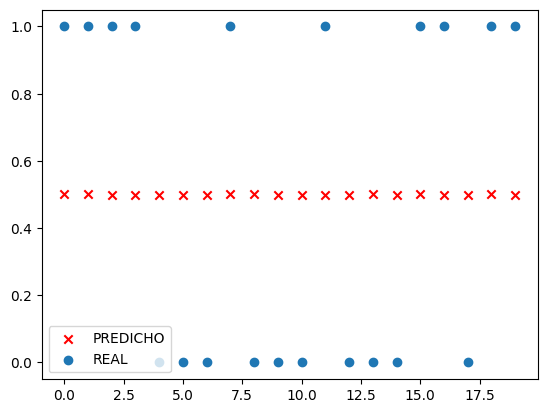

In [ ]:
# Datos
x = list(range(20))
y_real = test_labels
y_modelo = mu_ia

# Crear gráfica
plt.scatter(x,y_modelo, label = "PREDICHO", marker='x', color = 'red' )
plt.scatter(x, y_real, label = "REAL")

# Mostrar
plt.legend()
plt.show()

In [ ]:
print(train_df)

   filename                            Embedding_espectrograma  \
26   E_47_N  [tensor(0.1437), tensor(-0.6695), tensor(-2.19...   
2    E_29_G  [tensor(-0.0624), tensor(-0.6741), tensor(-2.1...   
24   E_28_G  [tensor(0.0119), tensor(-0.5538), tensor(-1.69...   
37   E_24_G  [tensor(-0.0434), tensor(-0.8476), tensor(-2.6...   
46   E_39_G  [tensor(-0.0303), tensor(-0.9181), tensor(-2.9...   
..      ...                                                ...   
30   E_20_N  [tensor(-0.0014), tensor(-0.9853), tensor(-3.2...   
58   E_43_N  [tensor(0.0942), tensor(-0.7008), tensor(-2.30...   
76   E_33_G  [tensor(-0.0895), tensor(-0.9464), tensor(-3.0...   
38   E_42_N  [tensor(0.0615), tensor(-0.8043), tensor(-2.75...   
42   E_17_N  [tensor(0.0124), tensor(-0.6560), tensor(-2.14...   

                            Embedding_caracteristicas  \
26  [tensor(0.), tensor(54.2982), tensor(242.2095)...   
2   [tensor(0.), tensor(40.9300), tensor(149.3829)...   
24  [tensor(0.), tensor(49.2093), te